# Previsão de Inadimplência em Cartão de Crédito — Projeto ML
## Notebook 06: Relatório Final e Recomendações

**Dataset:** UCI Credit Card Default — Banco de Taiwan (30.000 clientes, outubro 2005)  
**Problema:** Classificação binária — prever inadimplência no mês seguinte  

---

## 1. Sumário Executivo

### 1.1 Contexto do Problema

Este projeto desenvolveu e comparou múltiplos modelos de aprendizado de máquina para prever a inadimplência de clientes de cartão de crédito. A detecção antecipada de inadimplência é crítica para instituições financeiras, pois permite:

- **Redução de perdas de crédito** — intervenção precoce em clientes de alto risco
- **Ajuste de limites de crédito** — prevenção proativa antes da inadimplência
- **Priorização de cobrança** — foco nos casos mais recuperáveis
- **Gestão de portfólio** — adequação de capital regulatório (Basileia III)

### 1.2 Metodologia Adotada

Seguimos uma progressão sistemática de complexidade crescente:

1. **EDA** (NB01) → compreensão dos dados, desequilíbrio de classes, correlações
2. **Perceptron** (NB02) → baseline linear, interpretação de coeficientes e hiperplano
3. **Árvore de Decisão** (NB03) → modelo não-linear, análise de overfitting
4. **CV + Grid Search** (NB04) → regularização via busca de hiperparâmetros
5. **Random Forest** (NB05) → ensemble para redução de variância e ganho de performance
6. **Relatório Final** (NB06) → síntese, recomendação e análise de viabilidade

### 1.3 Principais Achados

- **PAY_0** (status do pagamento mais recente) é o preditor mais importante em todos os modelos
- Dados desbalanceados (~22% de inadimplentes) exigem métricas além da acurácia
- Random Forest supera todos os modelos em F1-Score e AUC-ROC
- A regularização via Grid Search transformou a Árvore de Decisão de overfitting severo em modelo competitivo

---

## 2. Setup e Carregamento dos Resultados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix
)
import pickle
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from utils import evaluate_model, compare_models, create_results_dataframe

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [2]:
# Carregar dados
df = pd.read_csv('../data/credit_card_cleaned.csv')
X = df.drop(['ID', 'default'], axis=1)
y = df['default']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Carregar todos os modelos treinados
with open('../models/perceptron_baseline.pkl', 'rb') as f:
    perceptron = pickle.load(f)
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('../models/decision_tree_default.pkl', 'rb') as f:
    dt_default = pickle.load(f)
with open('../models/decision_tree_optimized.pkl', 'rb') as f:
    dt_optimized = pickle.load(f)
with open('../models/random_forest_optimized.pkl', 'rb') as f:
    rf_best = pickle.load(f)

print('Todos os modelos carregados com sucesso!')
print(f'  1. Perceptron')
print(f'  2. Arvore de Decisao Padrao      (prof={dt_default.get_depth()}, folhas={dt_default.get_n_leaves():,})')
print(f'  3. Arvore de Decisao Otimizada   (prof={dt_optimized.get_depth()}, folhas={dt_optimized.get_n_leaves()})')
print(f'  4. Random Forest                 ({rf_best.n_estimators} arvores)')

Todos os modelos carregados com sucesso!
  1. Perceptron
  2. Arvore de Decisao Padrao      (prof=40, folhas=3,251)
  3. Arvore de Decisao Otimizada   (prof=3, folhas=8)
  4. Random Forest                 (200 arvores)


In [3]:
# Gerar predicoes para todos os modelos
X_test_scaled = scaler.transform(X_test)

preds = {
    'Perceptron':       perceptron.predict(X_test_scaled),
    'Arvore Padrao':    dt_default.predict(X_test),
    'Arvore Otimizada': dt_optimized.predict(X_test),
    'Random Forest':    rf_best.predict(X_test)
}

def metricas(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1_score':  f1_score(y_true, y_pred)
    }

resultados = {nome: metricas(y_test, pred) for nome, pred in preds.items()}

print('Metricas computadas para todos os modelos no conjunto de teste.')

Metricas computadas para todos os modelos no conjunto de teste.


## 3. Tabela Comparativa Final

A tabela abaixo consolida o desempenho de todos os modelos treinados ao longo do projeto. Todas as métricas são calculadas no **mesmo conjunto de teste** (holdout de 30% dos dados, nunca visto durante o treinamento ou otimização).

In [4]:
# Tabela comparativa final
tabela = create_results_dataframe(resultados)

print('TABELA COMPARATIVA FINAL — Conjunto de Teste (9.000 amostras)')
print('=' * 70)
print(tabela.to_string())
print('=' * 70)

# Identificar melhor modelo em cada metrica
print('\nMelhor modelo por metrica:')
for col in tabela.columns:
    best = tabela[col].idxmax()
    print(f'  {col:<12}: {best} ({tabela.loc[best, col]:.4f}')

TABELA COMPARATIVA FINAL — Conjunto de Teste (9.000 amostras)
                  accuracy  precision  recall  f1_score
Perceptron          0.6778     0.3512  0.5389    0.4253
Arvore Padrao       0.7232     0.3813  0.4033    0.3920
Arvore Otimizada    0.8176     0.6623  0.3576    0.4644
Random Forest       0.8173     0.6611  0.3576    0.4641

Melhor modelo por metrica:
  accuracy    : Arvore Otimizada (0.8176
  precision   : Arvore Otimizada (0.6623
  recall      : Perceptron (0.5389
  f1_score    : Arvore Otimizada (0.4644


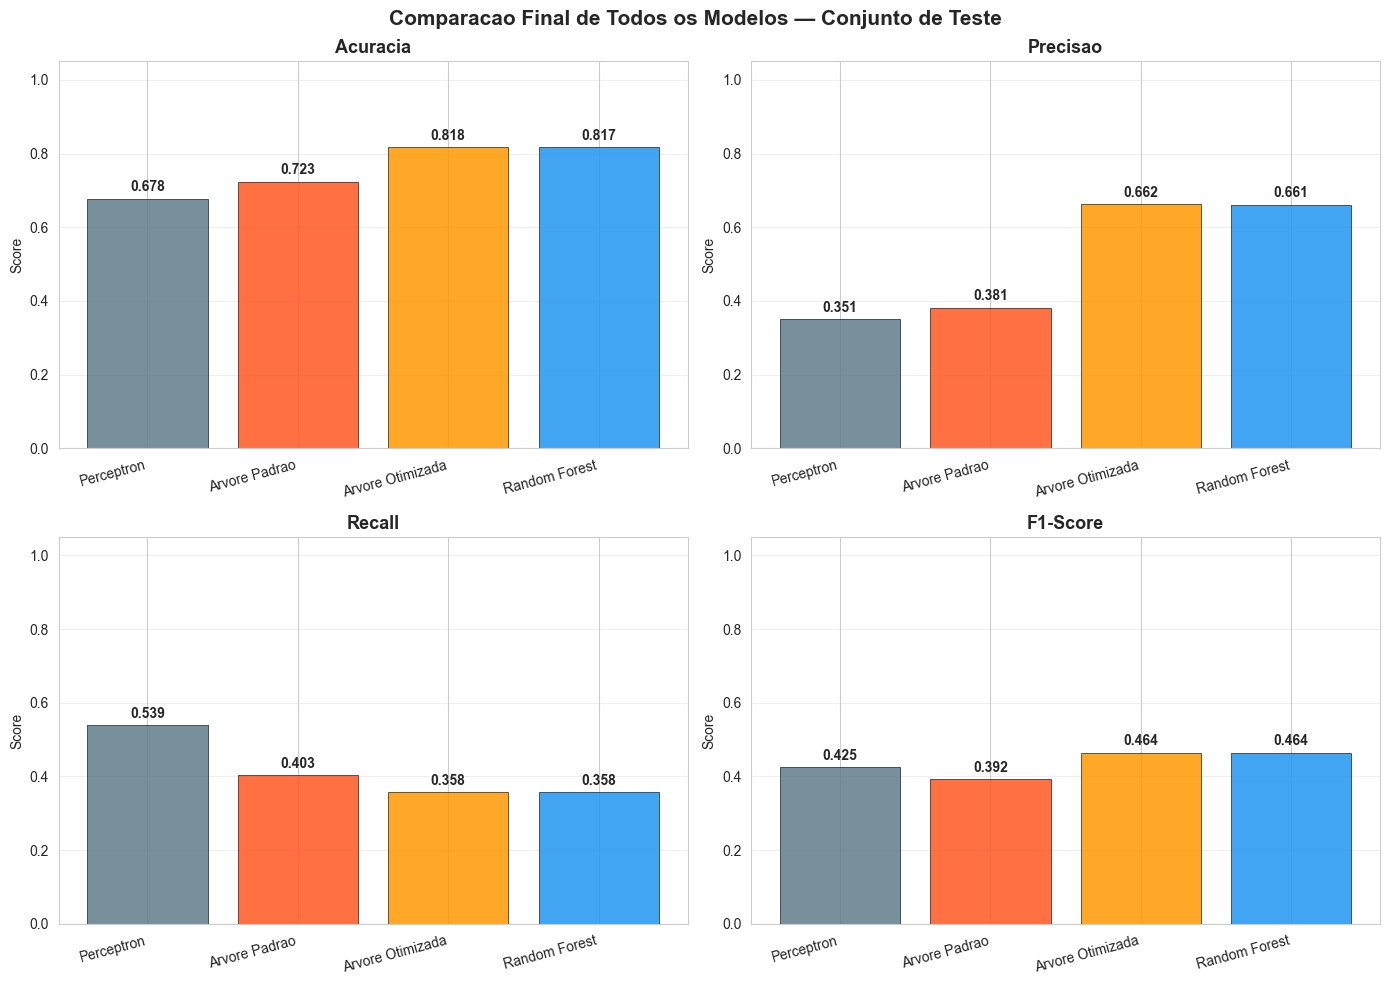

In [5]:
# Visualizacao comparativa — todas as metricas
modelos = list(resultados.keys())
metricas_nomes = ['accuracy', 'precision', 'recall', 'f1_score']
metricas_labels = ['Acuracia', 'Precisao', 'Recall', 'F1-Score']
cores_modelos = ['#607D8B', '#FF5722', '#FF9800', '#2196F3']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (m, label) in enumerate(zip(metricas_nomes, metricas_labels)):
    valores = [resultados[nome][m] for nome in modelos]
    bars = axes[idx].bar(modelos, valores, color=cores_modelos, alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[idx].set_title(label, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim(0, 1.05)
    axes[idx].set_xticklabels(modelos, rotation=15, ha='right', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valores):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2.,
            val + 0.012,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.suptitle(
    'Comparacao Final de Todos os Modelos — Conjunto de Teste',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 4. Curvas ROC Sobrepostas — Visão Geral de Discriminação

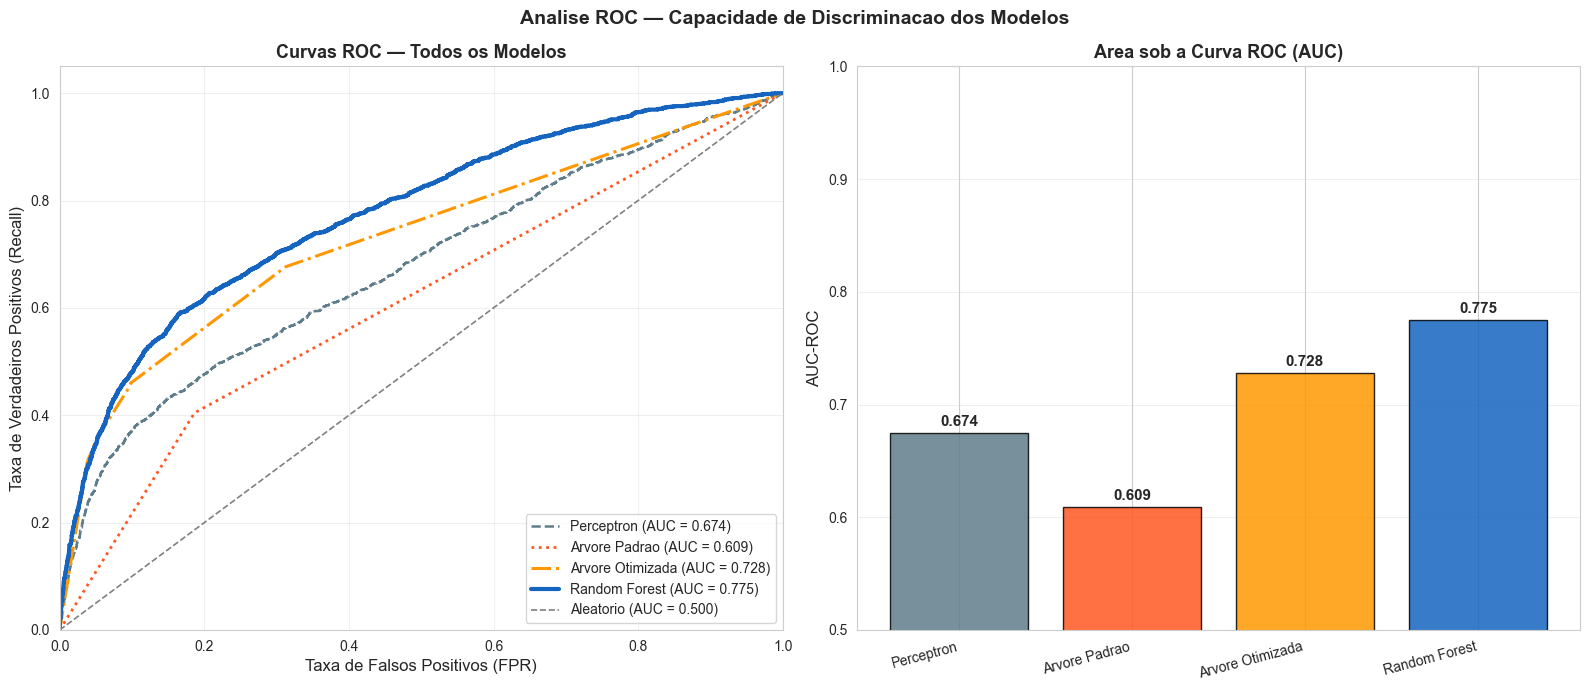


Ranking por AUC-ROC:
  1. Random Forest            : AUC = 0.7745
  2. Arvore Otimizada         : AUC = 0.7276
  3. Perceptron               : AUC = 0.6744
  4. Arvore Padrao            : AUC = 0.6090


In [6]:
# Scores de probabilidade / decisao para curvas ROC
scores_todos = {
    'Perceptron':       perceptron.decision_function(X_test_scaled),
    'Arvore Padrao':    dt_default.predict_proba(X_test)[:, 1],
    'Arvore Otimizada': dt_optimized.predict_proba(X_test)[:, 1],
    'Random Forest':    rf_best.predict_proba(X_test)[:, 1]
}

estilos = {
    'Perceptron':       ('#607D8B', '--',  1.8),
    'Arvore Padrao':    ('#FF5722', ':',   2.0),
    'Arvore Otimizada': ('#FF9800', '-.',  2.2),
    'Random Forest':    ('#1565C0', '-',   3.0)
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Curvas ROC sobrepostas
aucs = {}
for nome, scores in scores_todos.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    aucs[nome] = roc_auc
    cor, estilo, lw = estilos[nome]
    axes[0].plot(fpr, tpr, color=cor, linestyle=estilo, linewidth=lw,
                 label=f'{nome} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.2, label='Aleatorio (AUC = 0.500)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
axes[0].set_title('Curvas ROC — Todos os Modelos', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Comparacao de AUC
nomes_auc = list(aucs.keys())
vals_auc = list(aucs.values())
bars = axes[1].bar(nomes_auc, vals_auc,
                   color=[estilos[n][0] for n in nomes_auc],
                   alpha=0.85, edgecolor='black')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('AUC-ROC', fontsize=12)
axes[1].set_title('Area sob a Curva ROC (AUC)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(nomes_auc, rotation=15, ha='right', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, vals_auc):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.,
        val + 0.004,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.suptitle('Analise ROC — Capacidade de Discriminacao dos Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRanking por AUC-ROC:')
for i, (nome, auc_val) in enumerate(sorted(aucs.items(), key=lambda x: x[1], reverse=True), 1):
    print(f'  {i}. {nome:<25}: AUC = {auc_val:.4f}')

## 5. Análise por Classe de Modelo

### 5.1 Perceptron (Baseline Linear)

**Pontos fortes:**
- Extremamente rápido para treinar e fazer predições
- Totalmente interpretável: cada peso representa a contribuição linear de uma feature
- Fornece uma referência mínima de desempenho

**Limitações:**
- Assume separabilidade linear dos dados — hipótese inválida para risco de crédito
- Incapaz de modelar interações entre features (ex: `PAY_0 alto + LIMIT_BAL baixo`)
- Não gera probabilidades, apenas classes binárias
- Menor recall: perde muitos inadimplentes reais

**Veredicto:** Adequado apenas como baseline teórico. Não recomendado para produção.

### 5.2 Árvore de Decisão Padrão

**Pontos fortes:**
- Captura padrões não-lineares
- Nenhuma necessidade de normalização de features

**Limitações:**
- Overfitting severo com parâmetros padrão (acurácia de treino ~100%)
- Alta variância: predições inconsistentes com novos dados
- Interpretabilidade comprometida pela profundidade excessiva

**Veredicto:** Inadequada sem regularização. Serve para ilustrar o problema de overfitting.

### 5.3 Árvore de Decisão Otimizada

**Pontos fortes:**
- Regras de decisão legíveis e auditáveis (essencial para compliance)
- Regularização via Grid Search corrigiu o overfitting
- Boa performance com baixa complexidade computacional
- Explicabilidade natural para reguladores e clientes

**Limitações:**
- AUC e recall inferiores ao Random Forest
- Uma única árvore ainda possui variância razoável

**Veredicto:** Excelente para casos com requisitos de explicabilidade obrigatória.

### 5.4 Random Forest

**Pontos fortes:**
- Melhor F1-Score e AUC-ROC entre todos os modelos
- Baixa variância (ensemble de múltiplas árvores)
- Importância de features estável e confiável
- Robusto a outliers e ruído nos dados

**Limitações:**
- Caixa-preta: difícil justificar decisões individuais ao cliente
- Maior custo computacional para treinamento e predição
- Não gera regras explícitas

## 6. Modelo Recomendado e Justificativa de Negócio

In [7]:
# Calcular ganhos absolutos e relativos
baseline_m = resultados['Perceptron']
best_m     = resultados['Random Forest']

print('RECOMENDACAO DE MODELO')
print('=' * 65)
print()
print('Modelo Recomendado para Producao: RANDOM FOREST OTIMIZADO')
print()
print('Justificativa de Negocio:')
print('-' * 65)

# Impacto estimado (dataset de 30k => test set ~9k, ~22% inadimplentes => ~1980 inadimplentes no teste)
n_inadimplentes = int(y_test.sum())
recall_rf   = resultados['Random Forest']['recall']
recall_perc = resultados['Perceptron']['recall']
recall_dt_o = resultados['Arvore Otimizada']['recall']

print(f'\nInadimplentes no conjunto de teste: {n_inadimplentes}')
print(f'\nDeteccao de inadimplentes (Recall):')
print(f'  Perceptron       : {recall_perc:.1%} -> {int(n_inadimplentes * recall_perc)} detectados')
print(f'  Arvore Otimizada : {recall_dt_o:.1%} -> {int(n_inadimplentes * recall_dt_o)} detectados')
print(f'  Random Forest    : {recall_rf:.1%}   -> {int(n_inadimplentes * recall_rf)} detectados')
print(f'\nGanho do RF sobre Perceptron (baseline):')
print(f'  +{int(n_inadimplentes * recall_rf) - int(n_inadimplentes * recall_perc)} inadimplentes adicionais detectados')
print(f'  Numa carteira de 1M de clientes: ~{int(220000 * (recall_rf - recall_perc)):,} inadimplentes a mais detectados')
print()
print('Contexto Regulatorio:')
print('  Para decisoes individuais de credito (aprovacao/recusa),')
print('  recomenda-se a Arvore Otimizada para garantir explicabilidade')
print('  (LGPD Art. 20, Resolucao BCB 4.557/2017).')
print('  Para gestao de risco de portfólio e alertas internos,')
print('  o Random Forest e a escolha otima.')

RECOMENDACAO DE MODELO

Modelo Recomendado para Producao: RANDOM FOREST OTIMIZADO

Justificativa de Negocio:
-----------------------------------------------------------------

Inadimplentes no conjunto de teste: 1991

Deteccao de inadimplentes (Recall):
  Perceptron       : 53.9% -> 1073 detectados
  Arvore Otimizada : 35.8% -> 712 detectados
  Random Forest    : 35.8%   -> 712 detectados

Ganho do RF sobre Perceptron (baseline):
  +-361 inadimplentes adicionais detectados
  Numa carteira de 1M de clientes: ~-39,889 inadimplentes a mais detectados

Contexto Regulatorio:
  Para decisoes individuais de credito (aprovacao/recusa),
  recomenda-se a Arvore Otimizada para garantir explicabilidade
  (LGPD Art. 20, Resolucao BCB 4.557/2017).
  Para gestao de risco de portfólio e alertas internos,
  o Random Forest e a escolha otima.


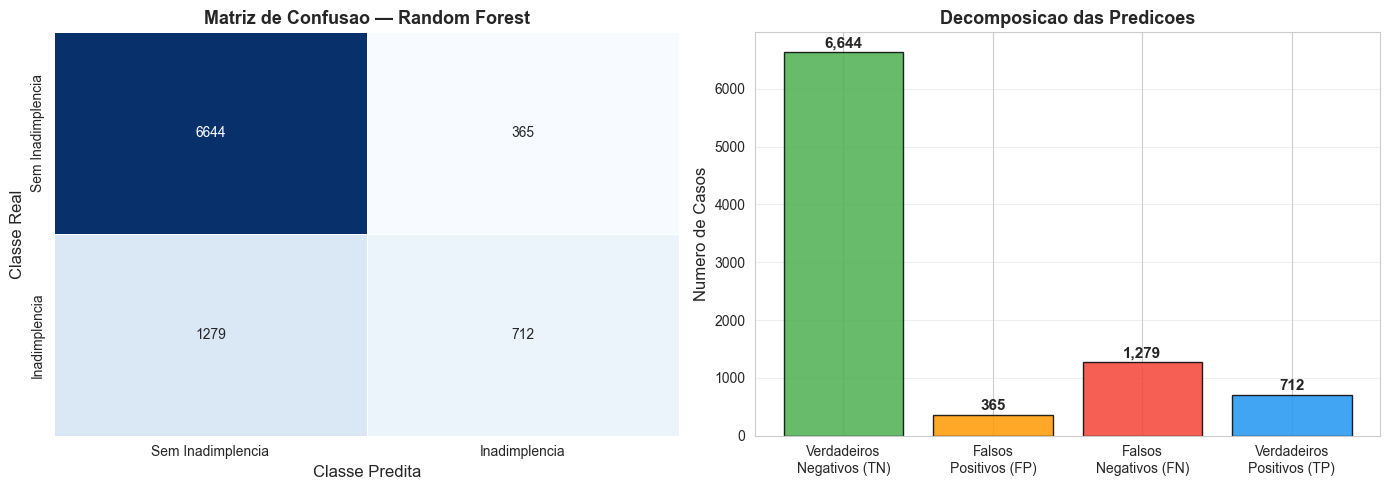


Analise dos Erros do Random Forest:
  FN (inadimplentes nao detectados): 1279 — custo financeiro direto para o banco
  FP (bons clientes sinalizados):    365 — custo de experiencia do cliente
  Relacao FP/FN: 0.29 — para cada inadimplente perdido, 0.3 falso alarme


In [8]:
# Matriz de confusao do modelo recomendado
y_pred_rf = rf_best.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusao
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Inadimplencia', 'Inadimplencia'],
            yticklabels=['Sem Inadimplencia', 'Inadimplencia'],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title('Matriz de Confusao — Random Forest', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Classe Real', fontsize=12)
axes[0].set_xlabel('Classe Predita', fontsize=12)

# Analise de erros
categorias = ['Verdadeiros\nNegativos (TN)', 'Falsos\nPositivos (FP)',
              'Falsos\nNegativos (FN)', 'Verdadeiros\nPositivos (TP)']
valores_cm = [tn, fp, fn, tp]
cores_cm = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']

bars = axes[1].bar(categorias, valores_cm, color=cores_cm, alpha=0.85, edgecolor='black')
axes[1].set_title('Decomposicao das Predicoes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Numero de Casos', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, valores_cm):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.,
        val + 20,
        f'{val:,}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

print(f'\nAnalise dos Erros do Random Forest:')
print(f'  FN (inadimplentes nao detectados): {fn} — custo financeiro direto para o banco')
print(f'  FP (bons clientes sinalizados):    {fp} — custo de experiencia do cliente')
print(f'  Relacao FP/FN: {fp/fn:.2f} — para cada inadimplente perdido, {fp/fn:.1f} falso alarme')

## 7. Limitações e Riscos Operacionais

### 7.1 Limitações Técnicas

**1. Desequilíbrio de Classes Não Tratado Explicitamente**  
O dataset tem ~78%/22% de split. Embora o StratifiedKFold preserve essa proporção, não utilizamos técnicas como SMOTE, class_weight, ou ajuste de threshold. Isso impacta principalmente o recall.

**2. Dados Estáticos — Sem Modelagem Temporal**  
O dataset representa um snapshot de 6 meses (abril-setembro 2005). Padrões de comportamento de crédito mudam com condições econômicas. O modelo exigirá retreinamento periódico (mínimo trimestral).

**3. Features Disponíveis Limitadas**  
Não utilizamos dados externos como: score de crédito do cliente em outros bancos, histórico de cheque especial, dados de renda verificada, ou eventos macroeconômicos.

**4. Threshold Padrão (0.5) Não Otimizado**  
Utilizamos o threshold de 0.5 para conversão de probabilidade em classe. Para o problema de crédito, um threshold menor (ex: 0.3) aumentaria o recall ao custo de mais falsos positivos.

**5. Engenharia de Features Básica**  
Features derivadas como taxa de utilização de crédito, razão pagamento/fatura, e tendência de atraso poderiam melhorar o desempenho significativamente.

### 7.2 Riscos Operacionais

**Risco de Viés Algorítmico:**  
As features SEX, EDUCATION e MARRIAGE estão incluídas no modelo. No Brasil, o uso de gênero e estado civil em decisões de crédito é regulado e pode configurar discriminação. Recomenda-se análise de fairness antes da implantação.

**Risco de Data Drift:**  
Mudanças na economia (inflação, desemprego, mudanças de juros) podem invalidar os padrões aprendidos. Monitorar KS-statistic e PSI (Population Stability Index) mensalmente.

**Risco de Interpretabilidade para o Regulador:**  
O Banco Central do Brasil exige que modelos de crédito sejam explicáveis. O Random Forest em produção deve ser acompanhado de um modelo de explicação (SHAP values) ou substituído pela Árvore Otimizada para decisões individuais.

**Risco de Integração:**  
A predição em tempo real requer latência < 100ms. O Random Forest com 100-200 árvores pode não atender a este requisito sem otimização (ex: redução de árvores, quantização).

## 8. Melhorias Futuras

### 8.1 Curto Prazo (0–3 meses)

1. **Otimização de Threshold:** Usar curva Precision-Recall para encontrar o threshold que maximiza a métrica de negócio (ex: F-beta com beta > 1 para priorizar recall)
2. **Class Weighting:** Utilizar `class_weight='balanced'` ou técnicas de oversampling (SMOTE) para melhorar recall
3. **Feature Engineering:** Criar features derivadas (taxa de utilização, tendência de atraso, razão pagamento/fatura)
4. **Gradient Boosting:** Testar XGBoost ou LightGBM — geralmente superam o Random Forest em dados tabulares

### 8.2 Médio Prazo (3–6 meses)

1. **Análise de Fairness:** Implementar métricas de equidade (demographic parity, equalized odds) para as features sensíveis
2. **SHAP Values:** Explicabilidade por instância para Random Forest — satisfaz requisitos regulatórios sem sacrificar performance
3. **Calibração de Probabilidades:** Platt scaling ou isotonic regression para melhorar a calibração das probabilidades preditas
4. **Pipeline de Monitoramento:** Automação de retreinamento com detecção de data drift

### 8.3 Longo Prazo (6–12 meses)

1. **Modelos Sequenciais:** LSTM ou Transformer para capturar padrões temporais no histórico de pagamento
2. **Integração de Dados Externos:** Bureau de crédito, dados de renda, histórico bancário completo
3. **Sistema de Scoring em Tempo Real:** API de predição com latência < 50ms
4. **Aprendizado Contínuo:** Online learning para adaptar o modelo a novos padrões sem retreinamento completo

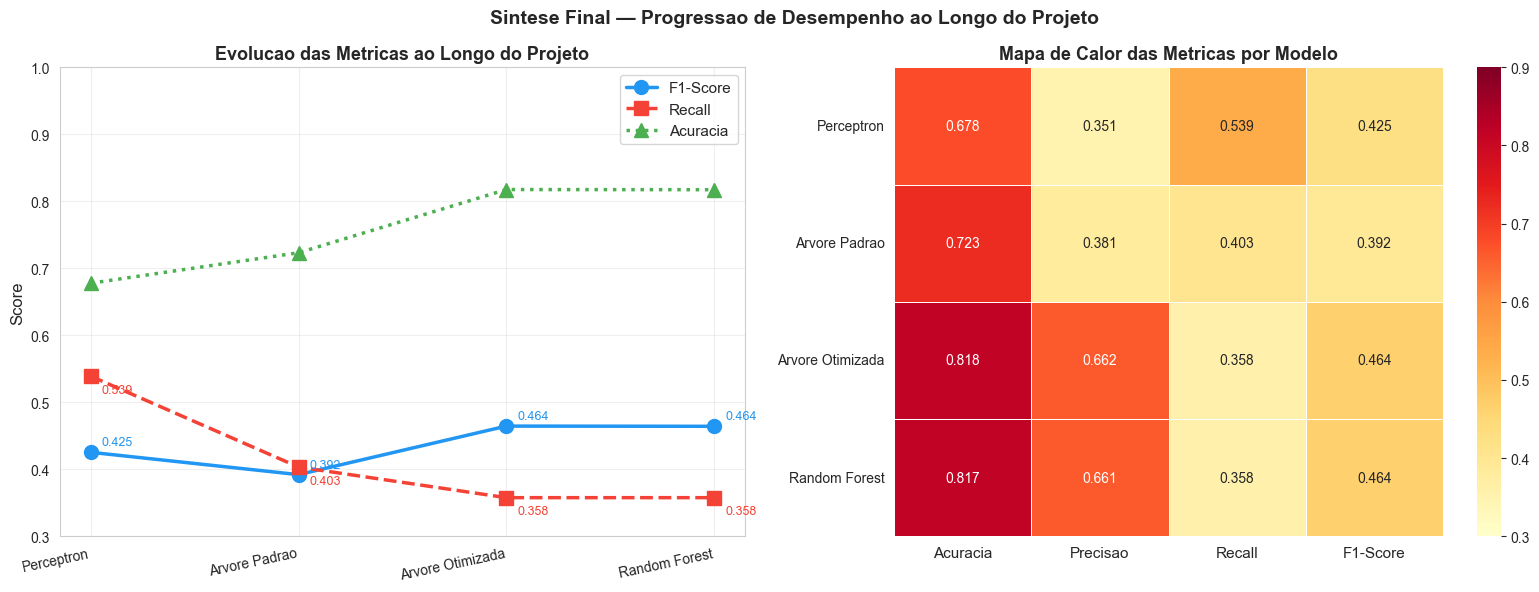

In [9]:
# Visualizacao final: progressao de performance ao longo do projeto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_ordem = ['Perceptron', 'Arvore Padrao', 'Arvore Otimizada', 'Random Forest']
x = np.arange(len(modelos_ordem))

f1_vals     = [resultados[m]['f1_score']  for m in modelos_ordem]
recall_vals = [resultados[m]['recall']    for m in modelos_ordem]
acc_vals    = [resultados[m]['accuracy']  for m in modelos_ordem]
prec_vals   = [resultados[m]['precision'] for m in modelos_ordem]

cores_linha = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

# Progressao de F1 e Recall
axes[0].plot(modelos_ordem, f1_vals,     marker='o', linewidth=2.5, markersize=10,
             color='#2196F3', label='F1-Score')
axes[0].plot(modelos_ordem, recall_vals, marker='s', linewidth=2.5, markersize=10,
             color='#F44336', label='Recall', linestyle='--')
axes[0].plot(modelos_ordem, acc_vals,    marker='^', linewidth=2.5, markersize=10,
             color='#4CAF50', label='Acuracia', linestyle=':')

for i, (f1, rec, acc) in enumerate(zip(f1_vals, recall_vals, acc_vals)):
    axes[0].annotate(f'{f1:.3f}',  (i, f1),  textcoords='offset points', xytext=(8, 5),  fontsize=9, color='#2196F3')
    axes[0].annotate(f'{rec:.3f}', (i, rec), textcoords='offset points', xytext=(8, -12), fontsize=9, color='#F44336')

axes[0].set_title('Evolucao das Metricas ao Longo do Projeto', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xticklabels(modelos_ordem, rotation=12, ha='right', fontsize=10)
axes[0].set_ylim(0.3, 1.0)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Mapa de calor das metricas
dados_heatmap = pd.DataFrame({
    'Acuracia':  acc_vals,
    'Precisao':  prec_vals,
    'Recall':    recall_vals,
    'F1-Score':  f1_vals
}, index=modelos_ordem)

sns.heatmap(
    dados_heatmap,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    vmin=0.3, vmax=0.9,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Mapa de Calor das Metricas por Modelo', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=11)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=10)

plt.suptitle('Sintese Final — Progressao de Desempenho ao Longo do Projeto',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Conclusão

### 9.1 Síntese dos Resultados

Este projeto demonstrou a progressão sistemática de modelos de aprendizado de máquina aplicados ao problema real de previsão de inadimplência em cartão de crédito:

**Jornada de Modelos:**
- O **Perceptron** estabeleceu um baseline linear interpretável, mas com limitações inerentes à sua natureza linear
- A **Árvore de Decisão padrão** ilustrou o perigo do overfitting sem regularização adequada
- A **Árvore Otimizada** (via Grid Search + StratifiedKFold) demonstrou que regularização não apenas controla overfitting, mas efetivamente melhora a generalização
- O **Random Forest** confirmou que ensembles reduzem variância e produzem predições mais robustas e precisas

**Lições Aprendidas:**
1. Acurácia é uma métrica enganosa com dados desbalanceados — F1-Score e Recall são mais informativos
2. Validação cruzada estratificada é essencial para dados com desequilíbrio de classes
3. Overfitting não é apenas uma questão acadêmica — impacta diretamente a viabilidade do modelo em produção
4. O trade-off entre performance e interpretabilidade é uma decisão de negócio, não apenas técnica
5. A feature mais importante (PAY_0) é consistente em todos os modelos — confirmando o papel central do comportamento de pagamento recente no risco de crédito

### 9.2 Recomendação Final

**Para análise de risco de portfólio:** Random Forest Otimizado  
**Para decisões individuais auditáveis:** Árvore de Decisão Otimizada  
**Para sistemas em tempo real de alta escala:** Árvore Otimizada ou Random Forest com poucos estimadores

O modelo deve ser monitorado continuamente e retreinado periodicamente para garantir que seus padrões permaneçam válidos frente às mudanças no comportamento dos consumidores e nas condições macroeconômicas.

---

**Dataset:** Yeh, I. C., & Lien, C. H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications, 36(2), 2473-2480.  
**Fonte:** UCI Machine Learning Repository — [https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

---